In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve


In [ ]:
df = pd.read_csv("C:\\Users\\user\\Downloads\\dataset.csv")

In [7]:
# 직무 스트레스 항목
df['Occupational_Stress_Sum'] = df[['OS1', 'OS2', 'OS3', 'OS4', 'OS5', 'OS6', 'OS7', 'OS8',
                                    'OS9', 'OS10', 'OS11', 'OS12', 'OS13', 'OS14',
                                    'OS15', 'OS16', 'OS17', 'OS18', 'OS19',
                                    'OS20', 'OS21', 'OS22', 'OS23',
                                    'OS24', 'OS25', 'OS26', 'OS27', 'OS28',
                                    'OS29', 'OS30', 'OS31',
                                    'OS32', 'OS33', 'OS34', 'OS35',
                                    'OS36', 'OS37', 'OS38', 'OS39',
                                    'OS40', 'OS41']].sum(axis=1)

# 정규화
scaler = MinMaxScaler()
df['Occupational_Stress_Normalized'] = scaler.fit_transform(df[['Occupational_Stress_Sum']])

# 0.5기준 이진화 
df['Occupational_Stress_Target'] = df['Occupational_Stress_Normalized'].apply(lambda x: 0 if x <= 0.5 else 1)

In [8]:
df.drop(columns=['OS1', 'OS2', 'OS3', 'OS4', 'OS5', 'OS6', 'OS7', 'OS8', 'OS9', 'OS10', 'OS11', 'OS12', 'OS13', 'OS14', 'OS15', 'OS16', 'OS17', 'OS18', 'OS19', 'OS20', 'OS21', 'OS22', 'OS23', 'OS24', 'OS25', 'OS26', 'OS27', 'OS28', 'OS29', 'OS30', 'OS31', 'OS32', 'OS33', 'OS34', 'OS35', 'OS36', 'OS37', 'OS38', 'OS39', 'OS40', 'OS41'], inplace=True)
df = df.drop(columns=['Occupational_Stress_Sum', 'Occupational_Stress_Normalized'])

In [ ]:
# 긍부정 척도 변경
reverse_col = ['JS2','JS3','JS5','JS10','JS11','JS13','JS16','JS18','JS19','JS20','JS21','JS23','JS24','JS26','JS28','JS29','JS34','JS35','JS36','JP4','JP5','JP6']
reverse_map = {1:5, 2:4, 3:3, 4:2, 5:1}
df[reverse_col]= df[reverse_col].replace(reverse_map)
df[reverse_col].head()

In [9]:
# 데이터 분할

X = df.drop(['Occupational_Stress_Target'], axis=1)  # Features
y = df['Occupational_Stress_Target']  # Target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify = y, random_state=42)

In [10]:
# 정규화

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [11]:
# 이상치 처리 - 평균값으로 대체
for column in X_train.columns:
    # Calculate IQR
    Q1 = X_train[column].quantile(0.25)
    Q3 = X_train[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Detect outliers
    outliers = X_train[(X_train[column] < lower_bound) | (X_train[column] > upper_bound)]
    
    mean_value = X_train[(X_train[column] >= lower_bound) & (X_train[column] <= upper_bound)][column].mean()
    X_train.loc[(X_train[column] < lower_bound) | (X_train[column] > upper_bound), column] = mean_value

In [12]:
# 두모델의 합집합 변수 선택 (합집합37+추가2=임의로 한듯?)
combined_features = [
    "JS36", "JS23", "JS35", "Household income", "JS33", "JS21", "JS17", "JS11", "JS24",
    "JS26", "JP4", "Sperm quality", "JS5", "JS6", "JS15", "JS4", "JS7", "Educational level",
    "JS20", "JS14", "JS22", "JS29", "JS10", "JS12", "JS2", "JS28", "JS18", "JS25", "JS8",
    "JS31", "JS30", "JP6", "JS3", "JS32", "JS16", "JS13", "JS19", "JS1", "JP5"
]



# 훈련데이터/테스트 데이터에 변수 적용
X_train_selected = X_train[combined_features]
X_test_selected = X_test[combined_features]

X_train = X_train_selected
X_test = X_test_selected



In [13]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

In [17]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [33]:
best_params = {}

# 탐색 횟수와 교차검증 축소
N_ITER = 5
CV = 3

# SHAP 오류 방지용 환경변수 설정 (선택)
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

for model_name, model in models.items():
    params = param_distributions[model_name]
    
    # 파라미터가 없는 모델은 튜닝 생략
    if len(params) == 0:
        print(f"Skipping {model_name} (no hyperparameters to tune)")
        best_params[model_name] = "Default parameters used"
        continue
    
    print(f"\n🔍 Running RandomizedSearchCV for {model_name}")
    clf = RandomizedSearchCV(
        estimator=model,
        param_distributions=params,
        n_iter=N_ITER,
        cv=CV,
        verbose=1,
        random_state=42,
        n_jobs=1   # 병렬 OFF (RAM 안정)
    )

    clf.fit(X_train, y_train)
    best_params[model_name] = clf.best_params_
    print(f"✅ Best parameters for {model_name}: {clf.best_params_}")

Skipping GaussianNB (no hyperparameters to tune)

🔍 Running RandomizedSearchCV for DecisionTreeClassifier
Fitting 3 folds for each of 5 candidates, totalling 15 fits
✅ Best parameters for DecisionTreeClassifier: {'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 50}

🔍 Running RandomizedSearchCV for RandomForestClassifier
Fitting 3 folds for each of 5 candidates, totalling 15 fits
✅ Best parameters for RandomForestClassifier: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': None}

🔍 Running RandomizedSearchCV for AdaBoostClassifier
Fitting 3 folds for each of 5 candidates, totalling 15 fits


c:\Users\user\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
c:\Users\user\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
c:\Users\user\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
c:\Users\user\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
c:\Users\user\an

✅ Best parameters for AdaBoostClassifier: {'n_estimators': 150, 'learning_rate': 0.1}

🔍 Running RandomizedSearchCV for LGBMClassifier
Fitting 3 folds for each of 5 candidates, totalling 15 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 104, number of negative: 60
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000181 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 209
[LightGBM] [Info] Number of data points in the train set: 164, number of used features: 39
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.634146 -> initscore=0.550046
[LightGBM] [Info] Start training from score 0.550046
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warn

In [34]:
from sklearn.exceptions import NotFittedError
from sklearn.metrics import accuracy_score, roc_auc_score

# 시각화 설정
sns.set_context("paper", font_scale=1.5)
plt.rcParams['figure.figsize'] = [6, 4]

results = {}  # 평가 지표 저장용 딕셔너리

for model_name, model in models.items():
    try:
        print(f"\n🚀 Running model: {model_name}")
        
        # best_params가 존재하는지 확인
        if isinstance(best_params[model_name], str) and "Default" in best_params[model_name]:
            optimized_model = model
        else:
            optimized_model = model.set_params(**best_params[model_name])

        # 모델 학습
        optimized_model.fit(X_train, y_train)

        # 예측
        y_pred = optimized_model.predict(X_test)

        # 선형회귀(회귀모델) 처리
        if model_name == 'LinearRegression':
            y_pred_binary = (y_pred > 0.5).astype(int)
            y_proba = y_pred
        else:
            # 확률 예측 또는 의사결정 함수
            if hasattr(optimized_model, "predict_proba"):
                y_proba = optimized_model.predict_proba(X_test)[:, 1]
            elif hasattr(optimized_model, "decision_function"):
                y_proba = optimized_model.decision_function(X_test)
            else:
                y_proba = y_pred
            y_pred_binary = y_pred

        # 성능 저장
        results[model_name] = {
            "accuracy": accuracy_score(y_test, y_pred_binary),
            "roc_auc": roc_auc_score(y_test, y_proba) if len(set(y_test)) == 2 else None
        }

    except NotFittedError:
        print(f"⚠️ {model_name} 모델 학습 실패 (NotFittedError)")
    except Exception as e:
        print(f"❌ {model_name} 실행 중 오류 발생: {e}")


🚀 Running model: GaussianNB

🚀 Running model: DecisionTreeClassifier

🚀 Running model: RandomForestClassifier

🚀 Running model: AdaBoostClassifier


c:\Users\user\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(



🚀 Running model: LGBMClassifier
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 157, number of negative: 90
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000168 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 216
[LightGBM] [Info] Number of data points in the train set: 247, number of used features: 39
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.635628 -> initscore=0.556436
[LightGBM] [Info] Start training from score 0.556436
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No furt

# Ensemble Model Creation

Training hard voting classifier
Training soft voting classifier

📊 Classification Report for Hard Voting:
              precision    recall  f1-score   support

           0     0.9474    0.7826    0.8571        23
           1     0.8837    0.9744    0.9268        39

    accuracy                         0.9032        62
   macro avg     0.9155    0.8785    0.8920        62
weighted avg     0.9073    0.9032    0.9010        62



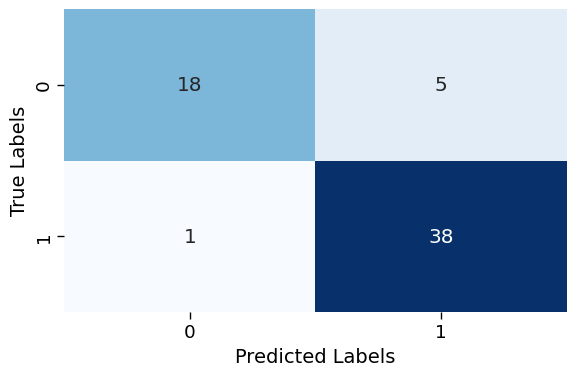

ROC-AUC Score for Hard Voting: 0.8785


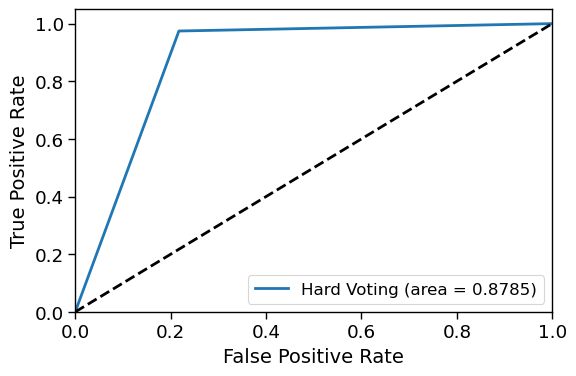


📊 Classification Report for Soft Voting:
              precision    recall  f1-score   support

           0     0.9474    0.7826    0.8571        23
           1     0.8837    0.9744    0.9268        39

    accuracy                         0.9032        62
   macro avg     0.9155    0.8785    0.8920        62
weighted avg     0.9073    0.9032    0.9010        62



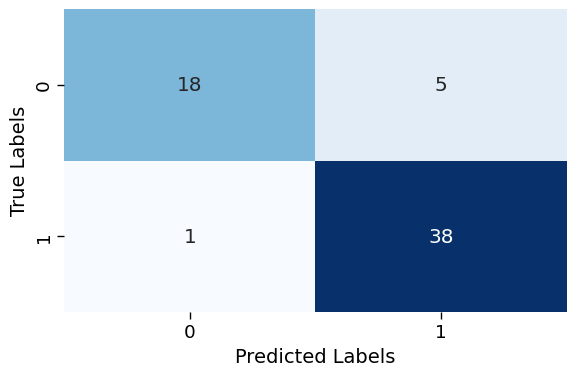

ROC-AUC Score for Soft Voting: 0.8807


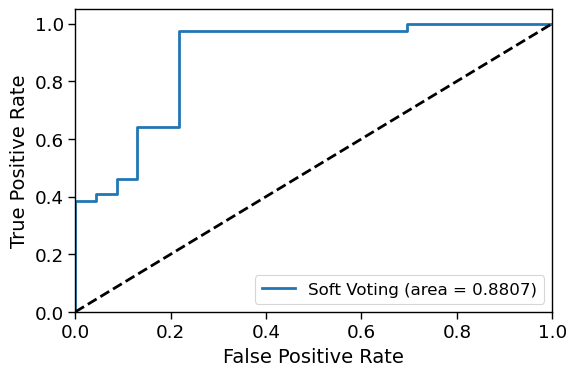

In [35]:
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import seaborn as sns
import matplotlib.pyplot as plt

# 플롯 설정
sns.set_context("paper", font_scale=1.5)
plt.rcParams['figure.figsize'] = [6, 4]

# 모델 생성
lr_best = LogisticRegression(**best_params['LogisticRegression'])
svc_best = SVC(**best_params['SVC'], probability=True)

# 하드 보팅
voting_clf_hard = VotingClassifier(
    estimators=[('lr', lr_best), ('svc', svc_best)],
    voting='hard'
)

# 소프트 보팅
voting_clf_soft = VotingClassifier(
    estimators=[('lr', lr_best), ('svc', svc_best)],
    voting='soft'
)

# 학습
print("Training hard voting classifier")
voting_clf_hard.fit(X_train, y_train)

print("Training soft voting classifier")
voting_clf_soft.fit(X_train, y_train)

# 평가
for clf, label in zip([voting_clf_hard, voting_clf_soft], ['Hard Voting', 'Soft Voting']):
    y_pred = clf.predict(X_test)

    # ROC-AUC용 확률 계산
    if hasattr(clf, "predict_proba"):
        y_proba = clf.predict_proba(X_test)[:, 1]
    elif hasattr(clf, "decision_function"):
        y_proba = clf.decision_function(X_test)
    else:
        y_proba = y_pred  # 예외 처리

    print(f"\n📊 Classification Report for {label}:")
    print(classification_report(y_test, y_pred, digits=4))

    # 혼동행렬
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.xlabel('Predicted Labels', fontsize=14)
    plt.ylabel('True Labels', fontsize=14)
    plt.tight_layout()
    plt.show()

    # ROC-AUC
    roc_auc = roc_auc_score(y_test, y_proba)
    print(f"ROC-AUC Score for {label}: {roc_auc:.4f}")

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, label=f'{label} (area = {roc_auc:.4f})', linewidth=2)
    plt.plot([0, 1], [0, 1], 'k--', linewidth=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=14)
    plt.ylabel('True Positive Rate', fontsize=14)
    plt.legend(loc="lower right", fontsize=12)
    plt.tight_layout()
    plt.show()

# Explainable AI

In [36]:
X_train.columns

Index(['JS36', 'JS23', 'JS35', 'Household income', 'JS33', 'JS21', 'JS17',
       'JS11', 'JS24', 'JS26', 'JP4', 'Sperm quality', 'JS5', 'JS6', 'JS15',
       'JS4', 'JS7', 'Educational level', 'JS20', 'JS14', 'JS22', 'JS29',
       'JS10', 'JS12', 'JS2', 'JS28', 'JS18', 'JS25', 'JS8', 'JS31', 'JS30',
       'JP6', 'JS3', 'JS32', 'JS16', 'JS13', 'JS19', 'JS1', 'JP5'],
      dtype='object')

In [37]:
X_test.columns

Index(['JS36', 'JS23', 'JS35', 'Household income', 'JS33', 'JS21', 'JS17',
       'JS11', 'JS24', 'JS26', 'JP4', 'Sperm quality', 'JS5', 'JS6', 'JS15',
       'JS4', 'JS7', 'Educational level', 'JS20', 'JS14', 'JS22', 'JS29',
       'JS10', 'JS12', 'JS2', 'JS28', 'JS18', 'JS25', 'JS8', 'JS31', 'JS30',
       'JP6', 'JS3', 'JS32', 'JS16', 'JS13', 'JS19', 'JS1', 'JP5'],
      dtype='object')

  0%|          | 0/50 [00:00<?, ?it/s]

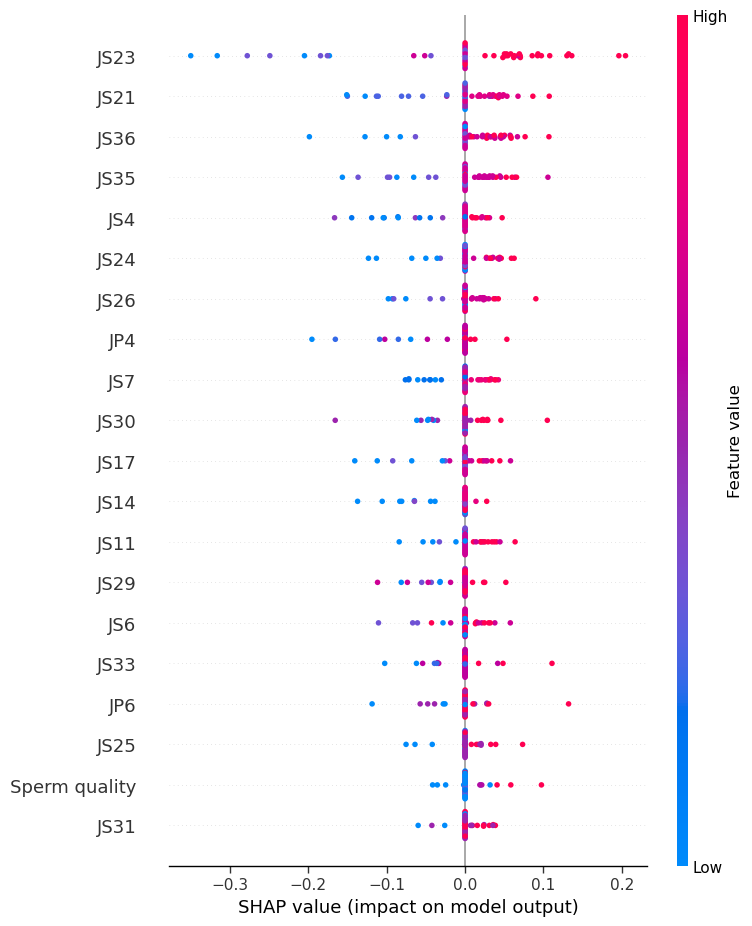

In [38]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# Hard voting 모델 (voting_clf_hard) 기준
explainer = shap.KernelExplainer(voting_clf_hard.predict, X_train.sample(100, random_state=42))  
# sample()로 일부만 사용해야 속도 문제 방지

# SHAP 값 계산 (테스트셋 중 일부)
shap_values = explainer.shap_values(X_test.sample(50, random_state=42), nsamples=100)

# summary plot
shap.summary_plot(shap_values, X_test.sample(50, random_state=42))

In [40]:
# 일부 샘플만 사용 (속도 문제 방지)
X_train_sample = X_train.sample(100, random_state=42)
X_test_sample = X_test.sample(50, random_state=42)

# KernelExplainer로 Hard Voting 모델 설명
explainer = shap.KernelExplainer(voting_clf_hard.predict, X_train_sample)

# SHAP 값 계산
shap_values = explainer.shap_values(X_test_sample, nsamples=100)

  0%|          | 0/50 [00:00<?, ?it/s]

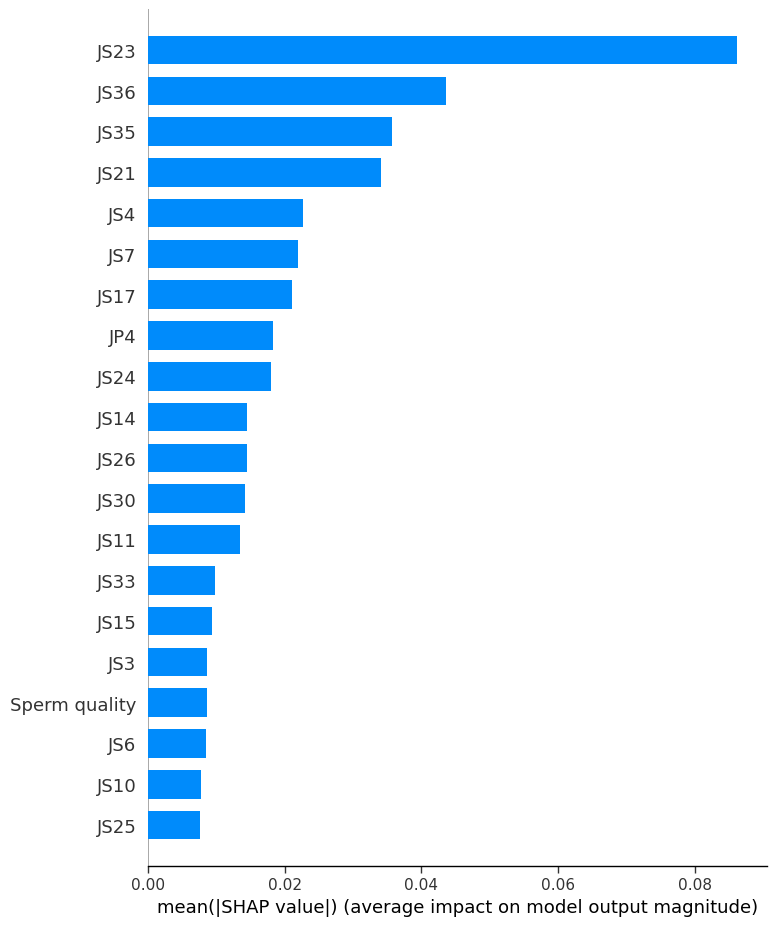

In [ ]:
# bar plot
# 변수 중요도 순위 한눈에 확인
# 방향성(양,음 영향은 표시 안됨)
shap.summary_plot(shap_values, X_test_sample, plot_type="bar")